In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import os

In [11]:
path = Path('..//..//results//2026-05-26T10-20-50Z//stages//preprocess//nn_inputs')

acc = np.load(Path(path, 'acc_inputs.npy'))

strain = np.load(Path(path, 'strain_inputs.npy'))

temp = np.load(Path(path, 'temperature_inputs.npy'))

event_ids = np.load(Path(path, 'event_ids.npy'))


In [ ]:
sensor_names = {
  "strain": [
    "NEW_S1_DO_INF_STR",
    "NEW_S1_DO_INF_STR",
    "NEW_S1_DO_INF_STR",
    "NEW_S1_DO_INF_STR",
    "NEW_S1_DO_INF_STR",
    "NEW_S1_DO_SUP_STR",
    "NEW_S1_DO_SUP_STR",
    "NEW_S1_DO_SUP_STR",
    "NEW_S1_DO_SUP_STR",
    "NEW_S1_DO_SUP_STR",
    "NEW_S1_UP_INF_STR",
    "NEW_S1_UP_INF_STR",
    "NEW_S1_UP_INF_STR",
    "NEW_S1_UP_INF_STR",
    "NEW_S1_UP_INF_STR",
    "NEW_S1_UP_SUP_STR",
    "NEW_S1_UP_SUP_STR",
    "NEW_S1_UP_SUP_STR",
    "NEW_S1_UP_SUP_STR",
    "NEW_S1_UP_SUP_STR",
    "NEW_S2_DO_INF_STR",
    "NEW_S2_DO_INF_STR",
    "NEW_S2_DO_INF_STR",
    "NEW_S2_DO_INF_STR",
    "NEW_S2_DO_INF_STR",
    "NEW_S2_DO_SUP_STR",
    "NEW_S2_DO_SUP_STR",
    "NEW_S2_DO_SUP_STR",
    "NEW_S2_DO_SUP_STR",
    "NEW_S2_DO_SUP_STR",
    "NEW_S2_UP_INF_STR",
    "NEW_S2_UP_INF_STR",
    "NEW_S2_UP_INF_STR",
    "NEW_S2_UP_INF_STR",
    "NEW_S2_UP_INF_STR",
    "NEW_S2_UP_SUP_STR",
    "NEW_S2_UP_SUP_STR",
    "NEW_S2_UP_SUP_STR",
    "NEW_S2_UP_SUP_STR",
    "NEW_S2_UP_SUP_STR"
  ],
  "acc_z": [
    "NEW_S1_DO_INT_ACC_Z",
    "NEW_S1_DO_INT_ACC_Z",
    "NEW_S1_DO_INT_ACC_Z",
    "NEW_S1_DO_INT_ACC_Z",
    "NEW_S1_DO_INT_ACC_Z",
    "NEW_S1_DO_MID_ACC_Z",
    "NEW_S1_DO_MID_ACC_Z",
    "NEW_S1_DO_MID_ACC_Z",
    "NEW_S1_DO_MID_ACC_Z",
    "NEW_S1_DO_MID_ACC_Z",
    "NEW_S1_UP_INT_ACC_Z",
    "NEW_S1_UP_INT_ACC_Z",
    "NEW_S1_UP_INT_ACC_Z",
    "NEW_S1_UP_INT_ACC_Z",
    "NEW_S1_UP_INT_ACC_Z",
    "NEW_S1_UP_MID_ACC_Z",
    "NEW_S1_UP_MID_ACC_Z",
    "NEW_S1_UP_MID_ACC_Z",
    "NEW_S1_UP_MID_ACC_Z",
    "NEW_S1_UP_MID_ACC_Z",
    "NEW_S2_DO_INT_ACC_Z",
    "NEW_S2_DO_INT_ACC_Z",
    "NEW_S2_DO_INT_ACC_Z",
    "NEW_S2_DO_INT_ACC_Z",
    "NEW_S2_DO_INT_ACC_Z",
    "NEW_S2_DO_MID_ACC_Z",
    "NEW_S2_DO_MID_ACC_Z",
    "NEW_S2_DO_MID_ACC_Z",
    "NEW_S2_DO_MID_ACC_Z",
    "NEW_S2_DO_MID_ACC_Z",
    "NEW_S2_UP_INT_ACC_Z",
    "NEW_S2_UP_INT_ACC_Z",
    "NEW_S2_UP_INT_ACC_Z",
    "NEW_S2_UP_INT_ACC_Z",
    "NEW_S2_UP_INT_ACC_Z",
    "NEW_S2_UP_MID_ACC_Z",
    "NEW_S2_UP_MID_ACC_Z",
    "NEW_S2_UP_MID_ACC_Z",
    "NEW_S2_UP_MID_ACC_Z",
    "NEW_S2_UP_MID_ACC_Z"
  ]
}


'NEW_S1_DO_INF_STR'

In [14]:
strain.shape

(12107, 200, 40)

In [106]:
#Wanting to get familiar with the data, first of all
#Making a simple statistical baseline for strain and accelerometer data
#to see whether the data changes over time

#Just taking mu = SET1.mean, sigma = SET1.std and computing the z-score for each run separately
#Doing this for each sensor (40 sensors) + each strain/accelerometer


### Evaluating Strain Gauges using different methods

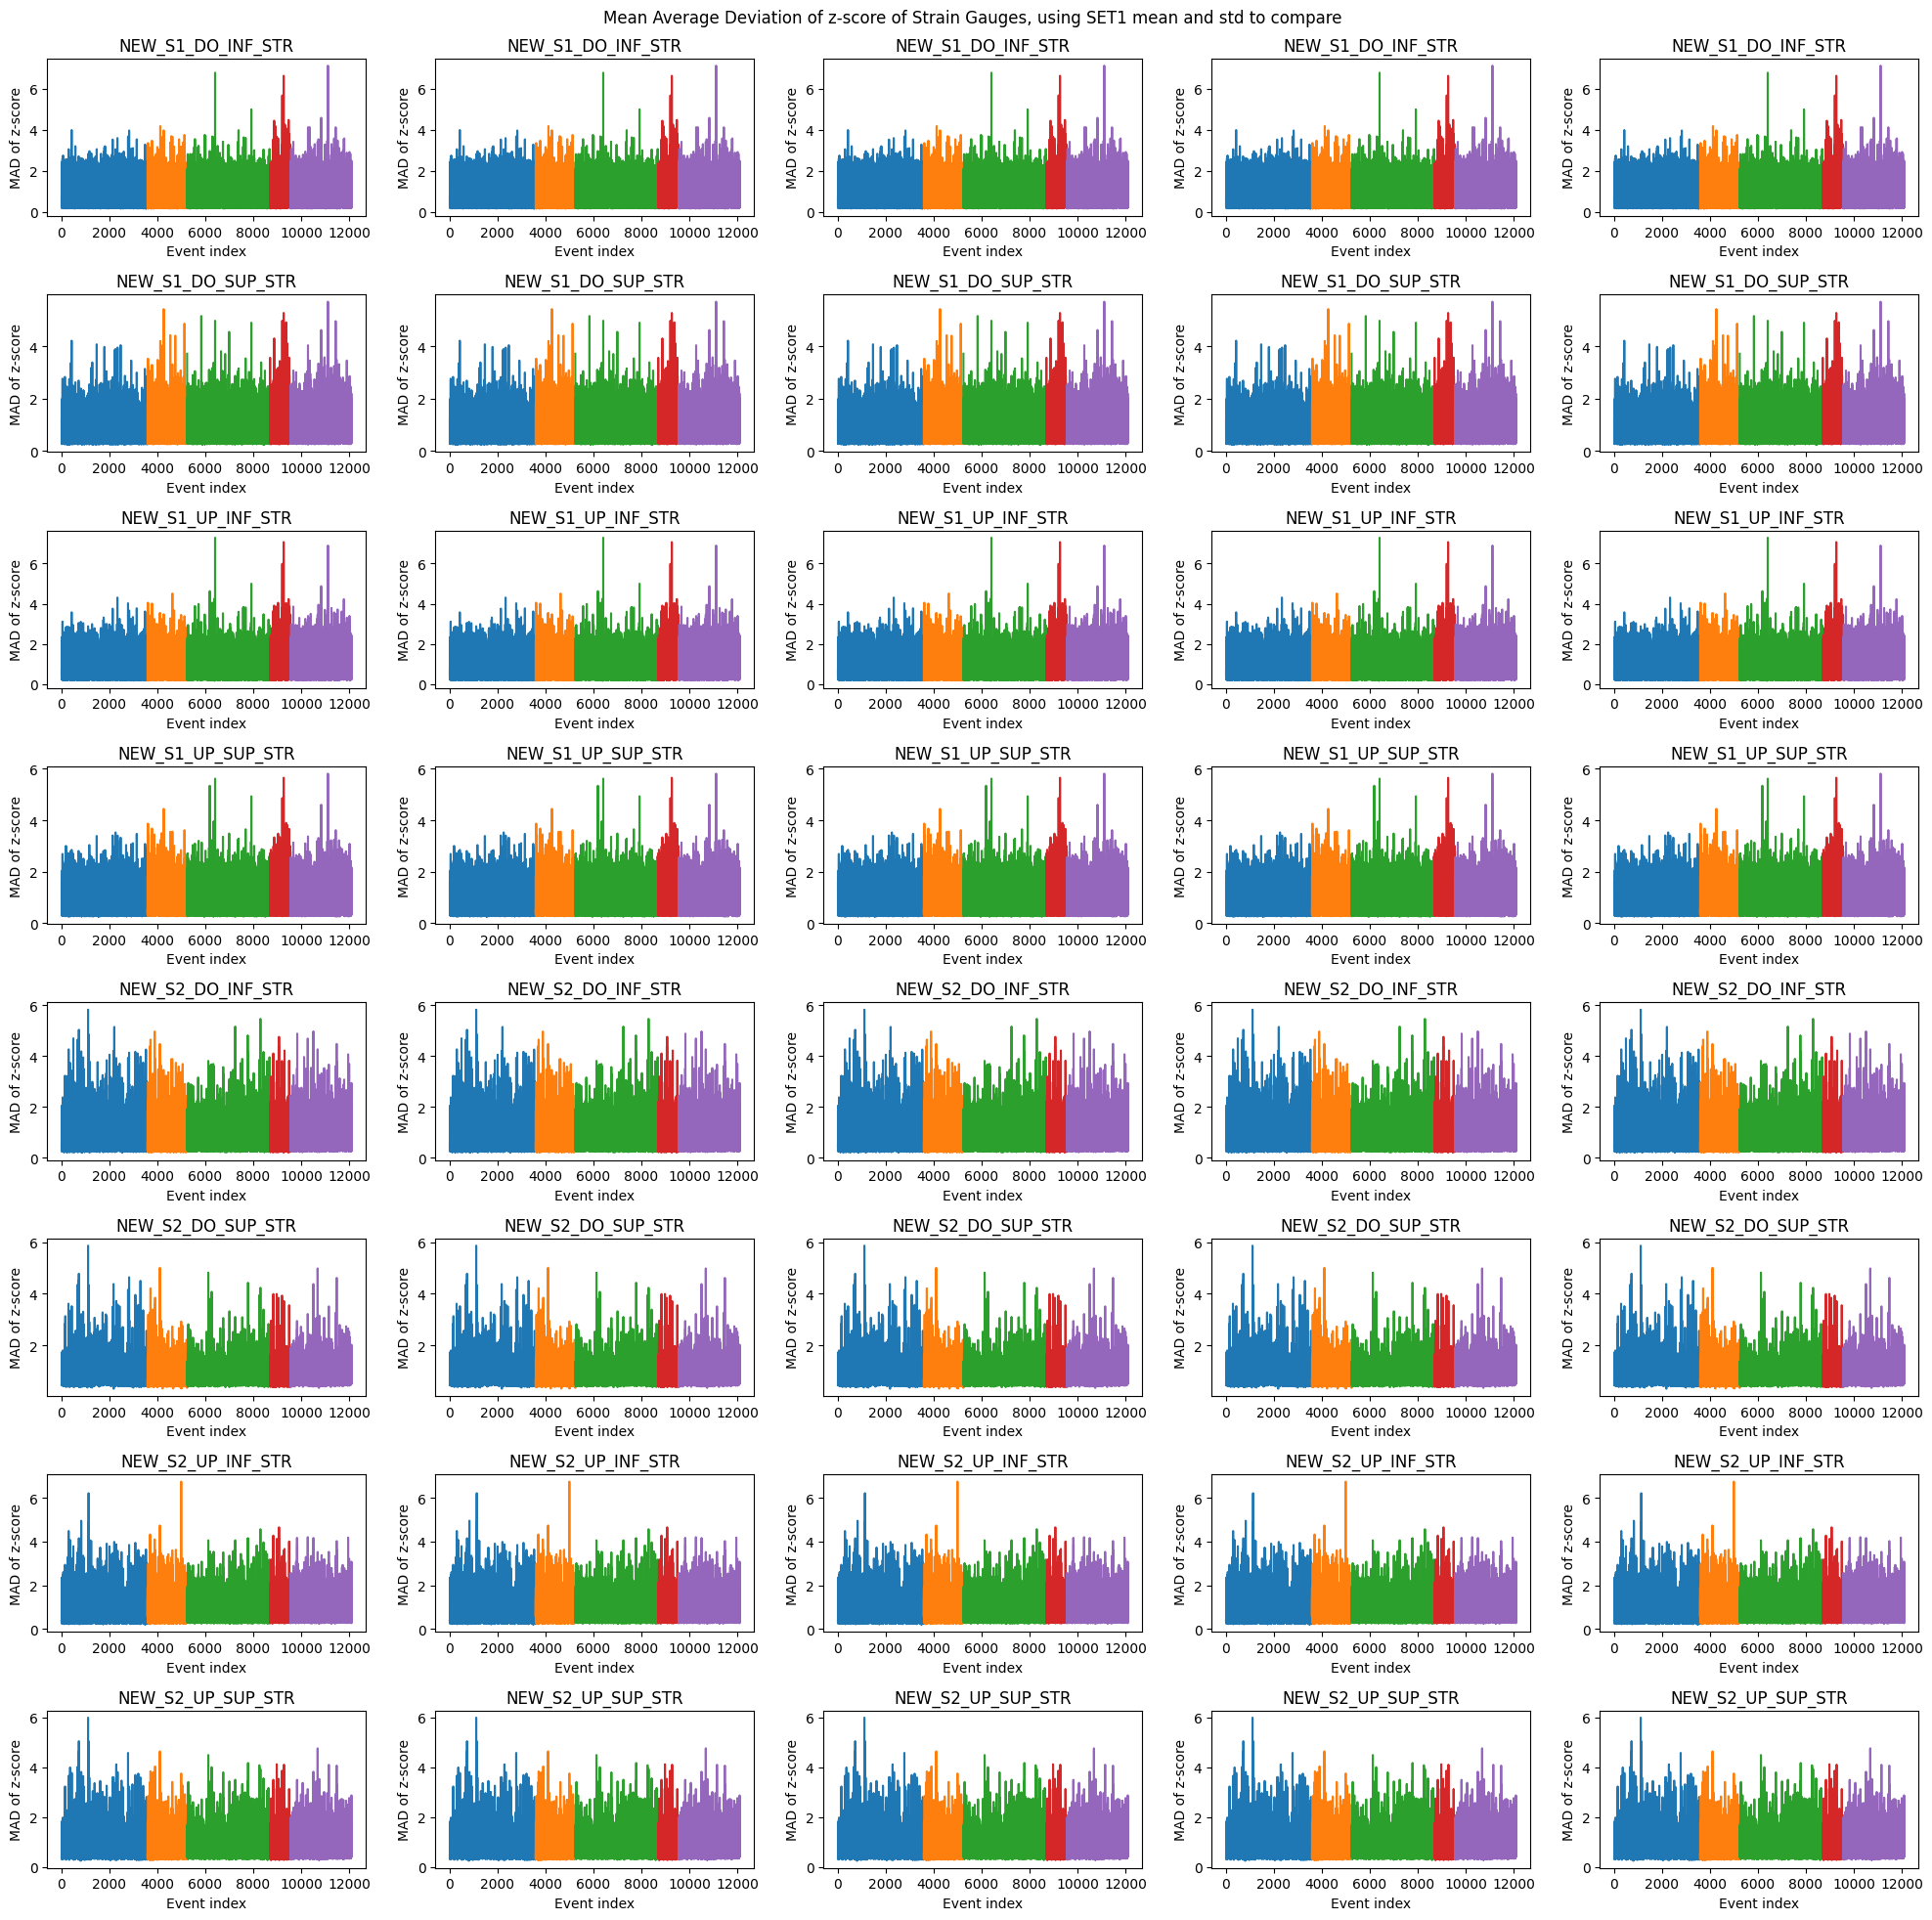

In [117]:
mask = [event_id.startswith('AQUINAS_SET1') for event_id in event_ids]

mu = strain[mask].mean(axis = 0)
sigma = strain[mask].std(axis = 0)


sets = ['AQUINAS_SET1','AQUINAS_SET2','AQUINAS_SET3','AQUINAS_SET4','AQUINAS_SET5']

plt.figure(figsize = (20,20))
idx = 0
for set_name in sets:

    set_mask = [event_id.startswith(set_name) for event_id in event_ids]

    set_z = (strain[set_mask] - mu) / sigma

    set_mad = np.mean(np.abs(set_z), axis = 1)

    for i in range(set_mad.shape[1]):
        plt.subplot(8,5,i+1)
        plt.plot(np.arange(idx, len(set_mad)+idx),set_mad[:,i])
        plt.title(sensor_names['strain'][i])
        plt.ylabel('MAD of z-score')
        plt.xlabel('Event index')

    idx += len(set_mad)


plt.suptitle('Mean Average Deviation of z-score of Strain Gauges, using SET1 mean and std to compare\n')
plt.tight_layout()
plt.show()


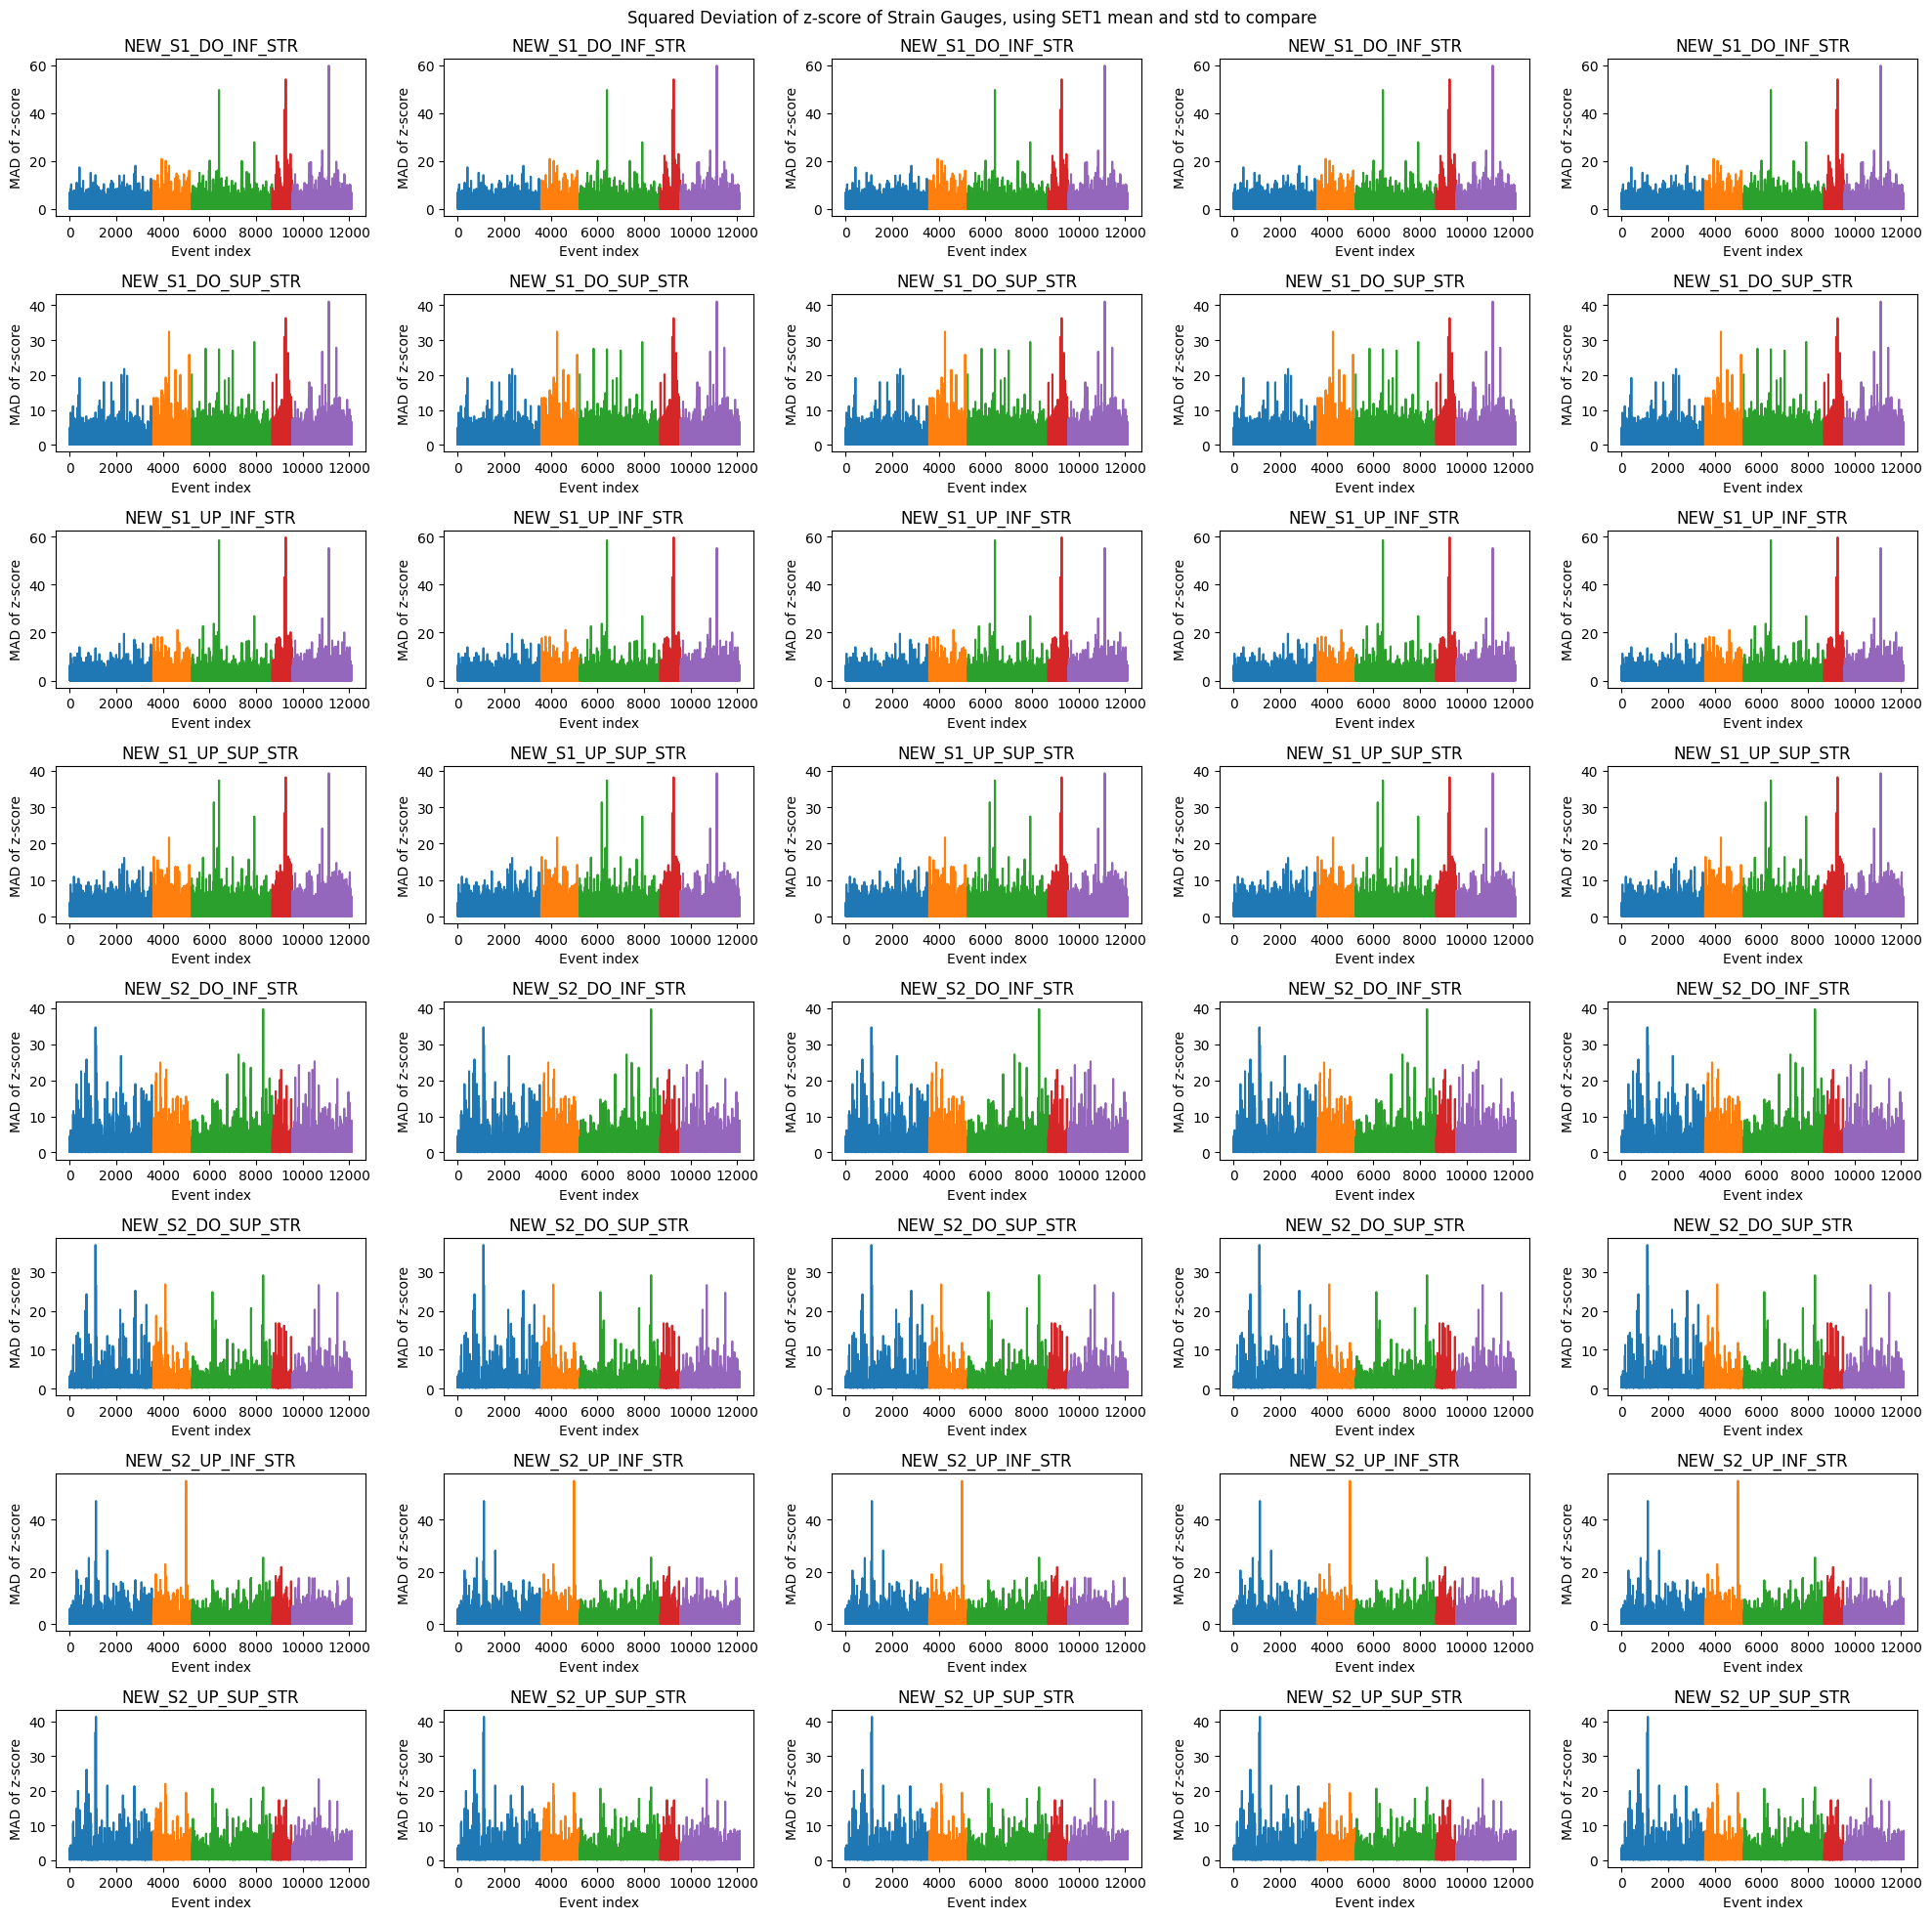

In [118]:
mask = [event_id.startswith('AQUINAS_SET1') for event_id in event_ids]

mu = strain[mask].mean(axis = 0)
sigma = strain[mask].std(axis = 0)


sets = ['AQUINAS_SET1','AQUINAS_SET2','AQUINAS_SET3','AQUINAS_SET4','AQUINAS_SET5']

plt.figure(figsize = (20,20))
idx = 0
for set_name in sets:

    set_mask = [event_id.startswith(set_name) for event_id in event_ids]

    set_z = (strain[set_mask] - mu) / sigma

    set_mad = np.mean((set_z)**2, axis = 1)

    for i in range(set_mad.shape[1]):
        plt.subplot(8,5,i+1)
        plt.plot(np.arange(idx, len(set_mad)+idx),set_mad[:,i])
        plt.title(sensor_names['strain'][i])
        plt.ylabel('MAD of z-score')
        plt.xlabel('Event index')

    idx += len(set_mad)


plt.suptitle('Squared Deviation of z-score of Strain Gauges, using SET1 mean and std to compare\n')
plt.tight_layout()
plt.show()


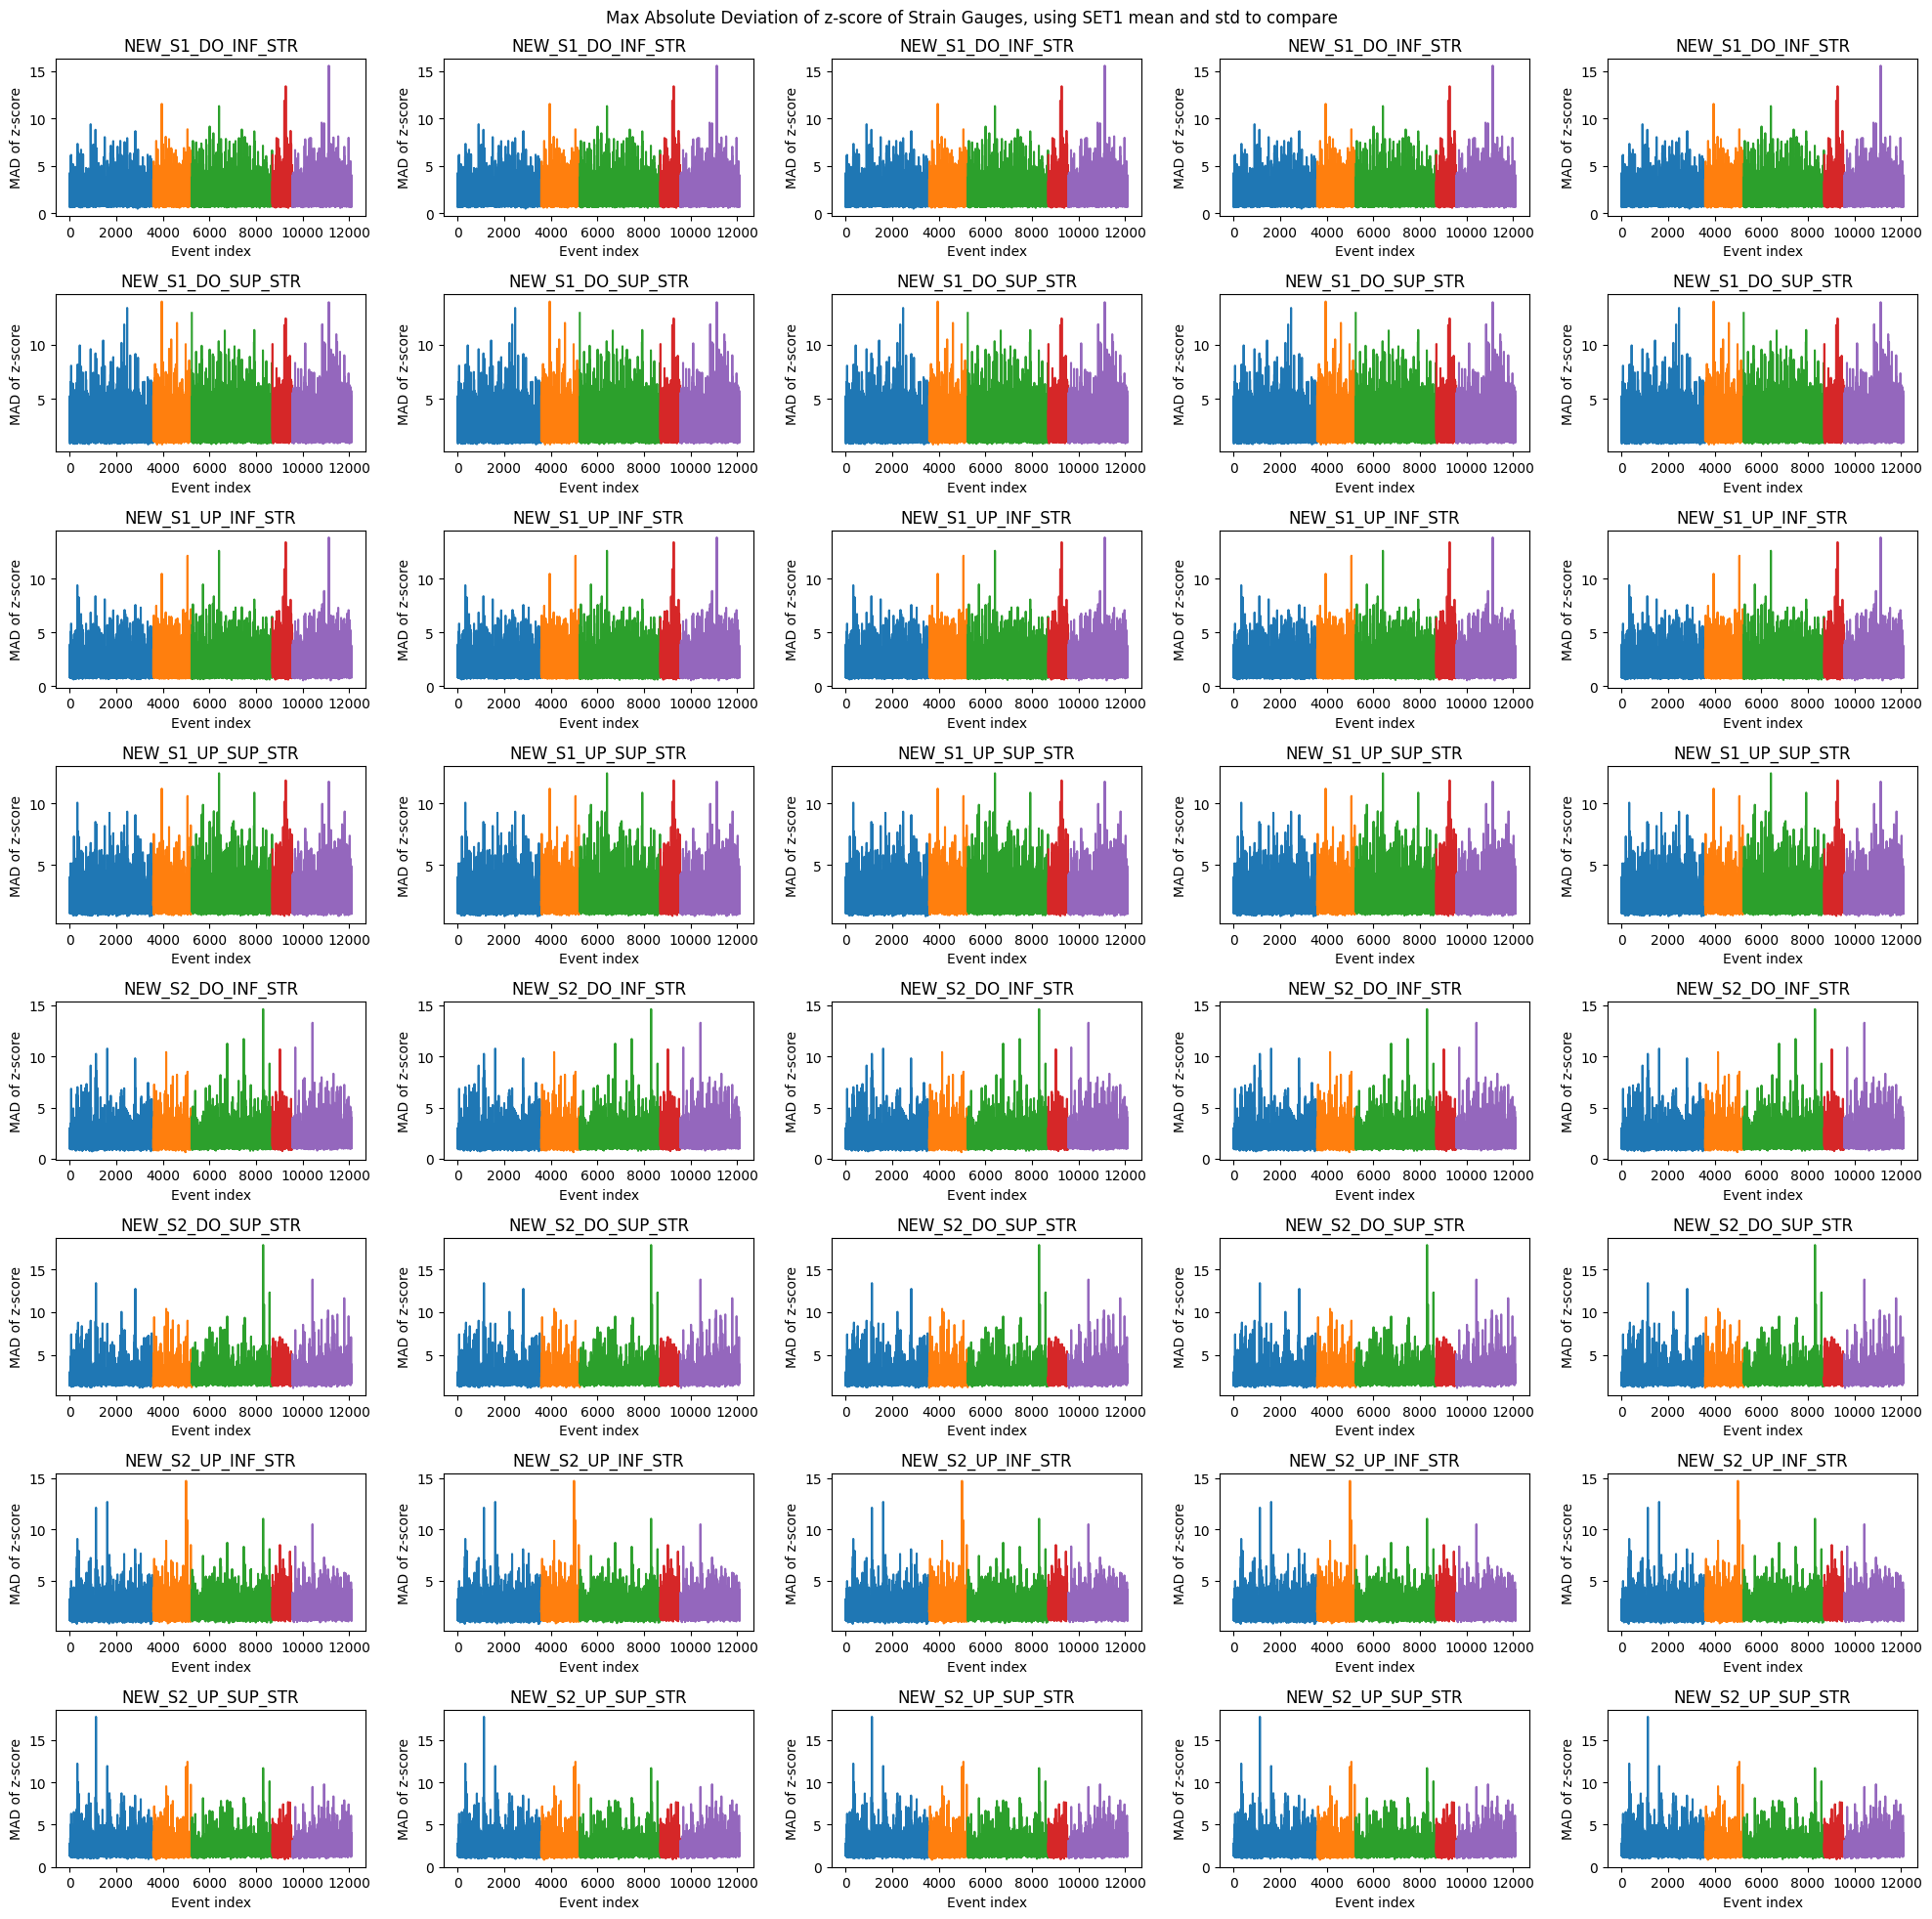

In [119]:
mask = [event_id.startswith('AQUINAS_SET1') for event_id in event_ids]

mu = strain[mask].mean(axis = 0)
sigma = strain[mask].std(axis = 0)


sets = ['AQUINAS_SET1','AQUINAS_SET2','AQUINAS_SET3','AQUINAS_SET4','AQUINAS_SET5']

plt.figure(figsize = (20,20))
idx = 0
for set_name in sets:

    set_mask = [event_id.startswith(set_name) for event_id in event_ids]

    set_z = (strain[set_mask] - mu) / sigma

    set_mad = np.max(np.abs(set_z), axis = 1)

    for i in range(set_mad.shape[1]):
        plt.subplot(8,5,i+1)
        plt.plot(np.arange(idx, len(set_mad)+idx),set_mad[:,i])
        plt.title(sensor_names['strain'][i])
        plt.ylabel('MAD of z-score')
        plt.xlabel('Event index')

    idx += len(set_mad)


plt.suptitle('Max Absolute Deviation of z-score of Strain Gauges, using SET1 mean and std to compare\n')
plt.tight_layout()
plt.show()


In [125]:
from sklearn.ensemble import IsolationForest

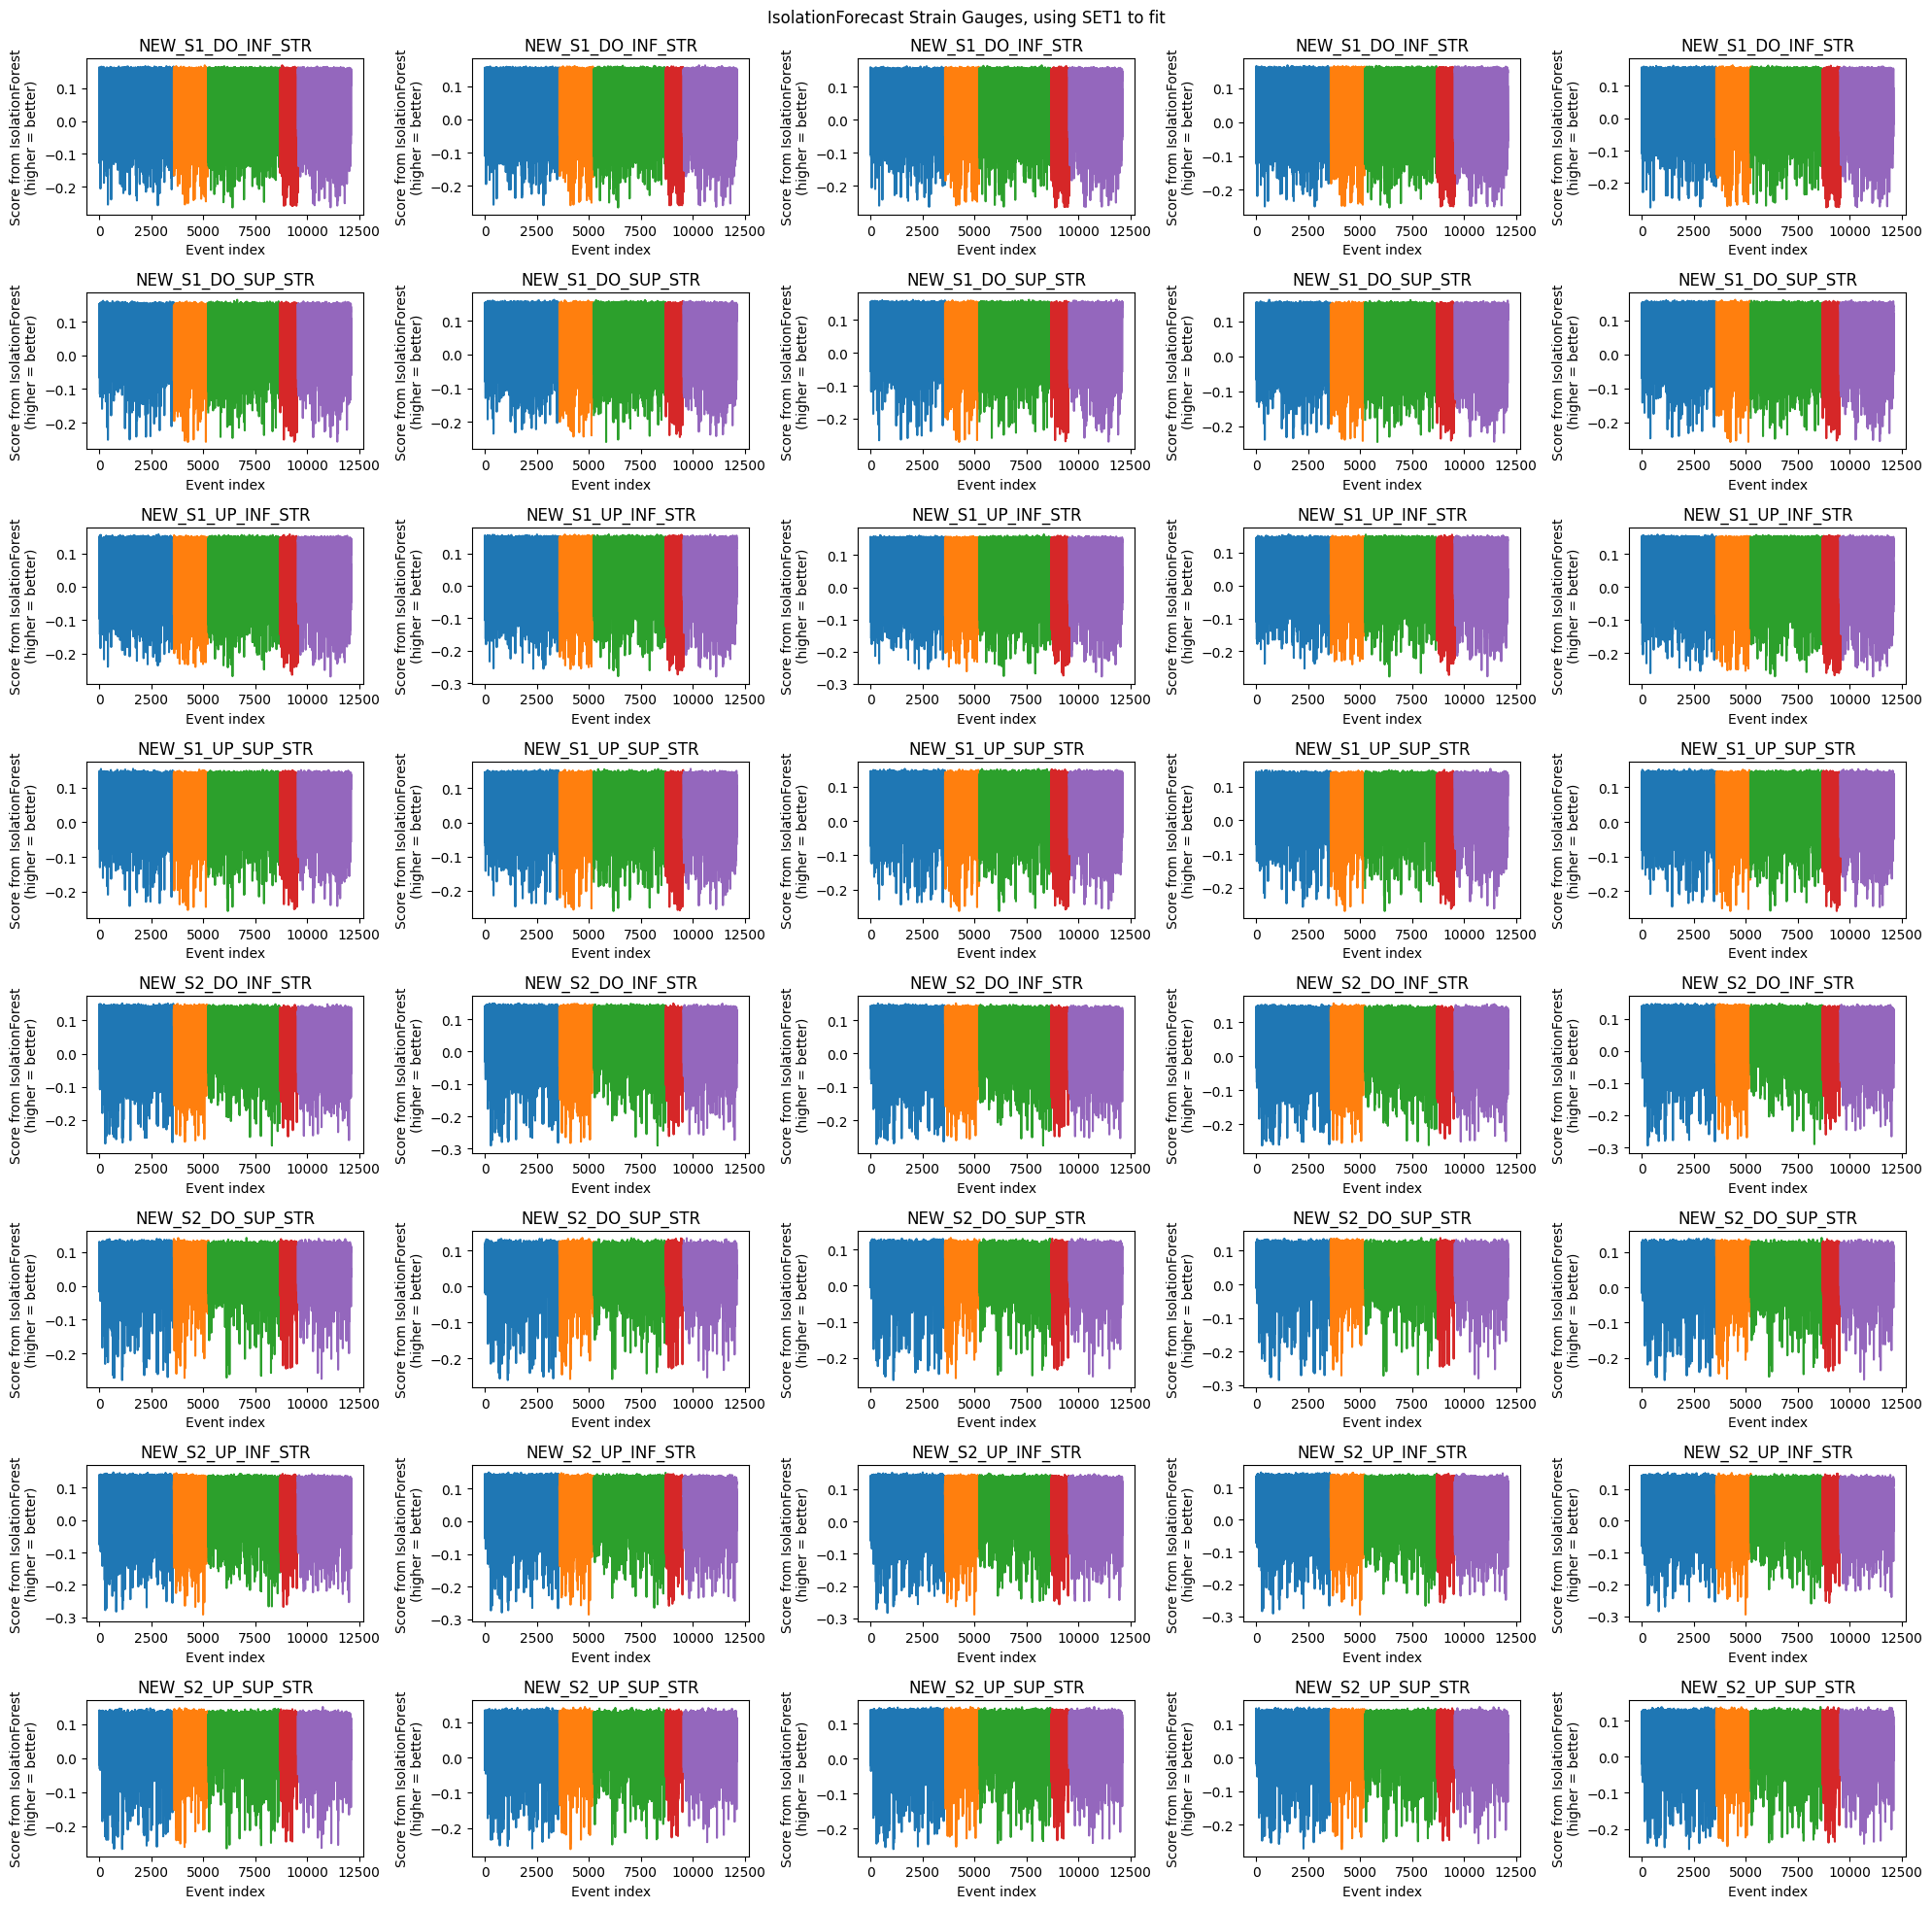

In [148]:
mask = [event_id.startswith('AQUINAS_SET1') for event_id in event_ids]

isos = [IsolationForest() for i in range(40)]

[isos[i].fit(strain[mask][:,:,i]) for i in range(40)]


plt.figure(figsize = (20,20))
idx = 0
for set_name in sets:

    set_mask = [event_id.startswith(set_name) for event_id in event_ids]

    #This one gives a score-per-event from IsolationForest
    set_mad = [isos[i].decision_function(strain[set_mask][:,:,i]) for i in range(40)]

    for i in range(40):
        plt.subplot(8,5,i+1)
        plt.plot(np.arange(idx, len(set_mad[i])+idx),set_mad[i])
        plt.title(sensor_names['strain'][i])
        plt.ylabel('Score from IsolationForest\n(higher = better)')
        plt.xlabel('Event index')

    idx += len(set_mad[i])


plt.suptitle('IsolationForecast Strain Gauges, using SET1 to fit\n')
plt.tight_layout()
plt.show()

### Evaluating accelerometers using different methods

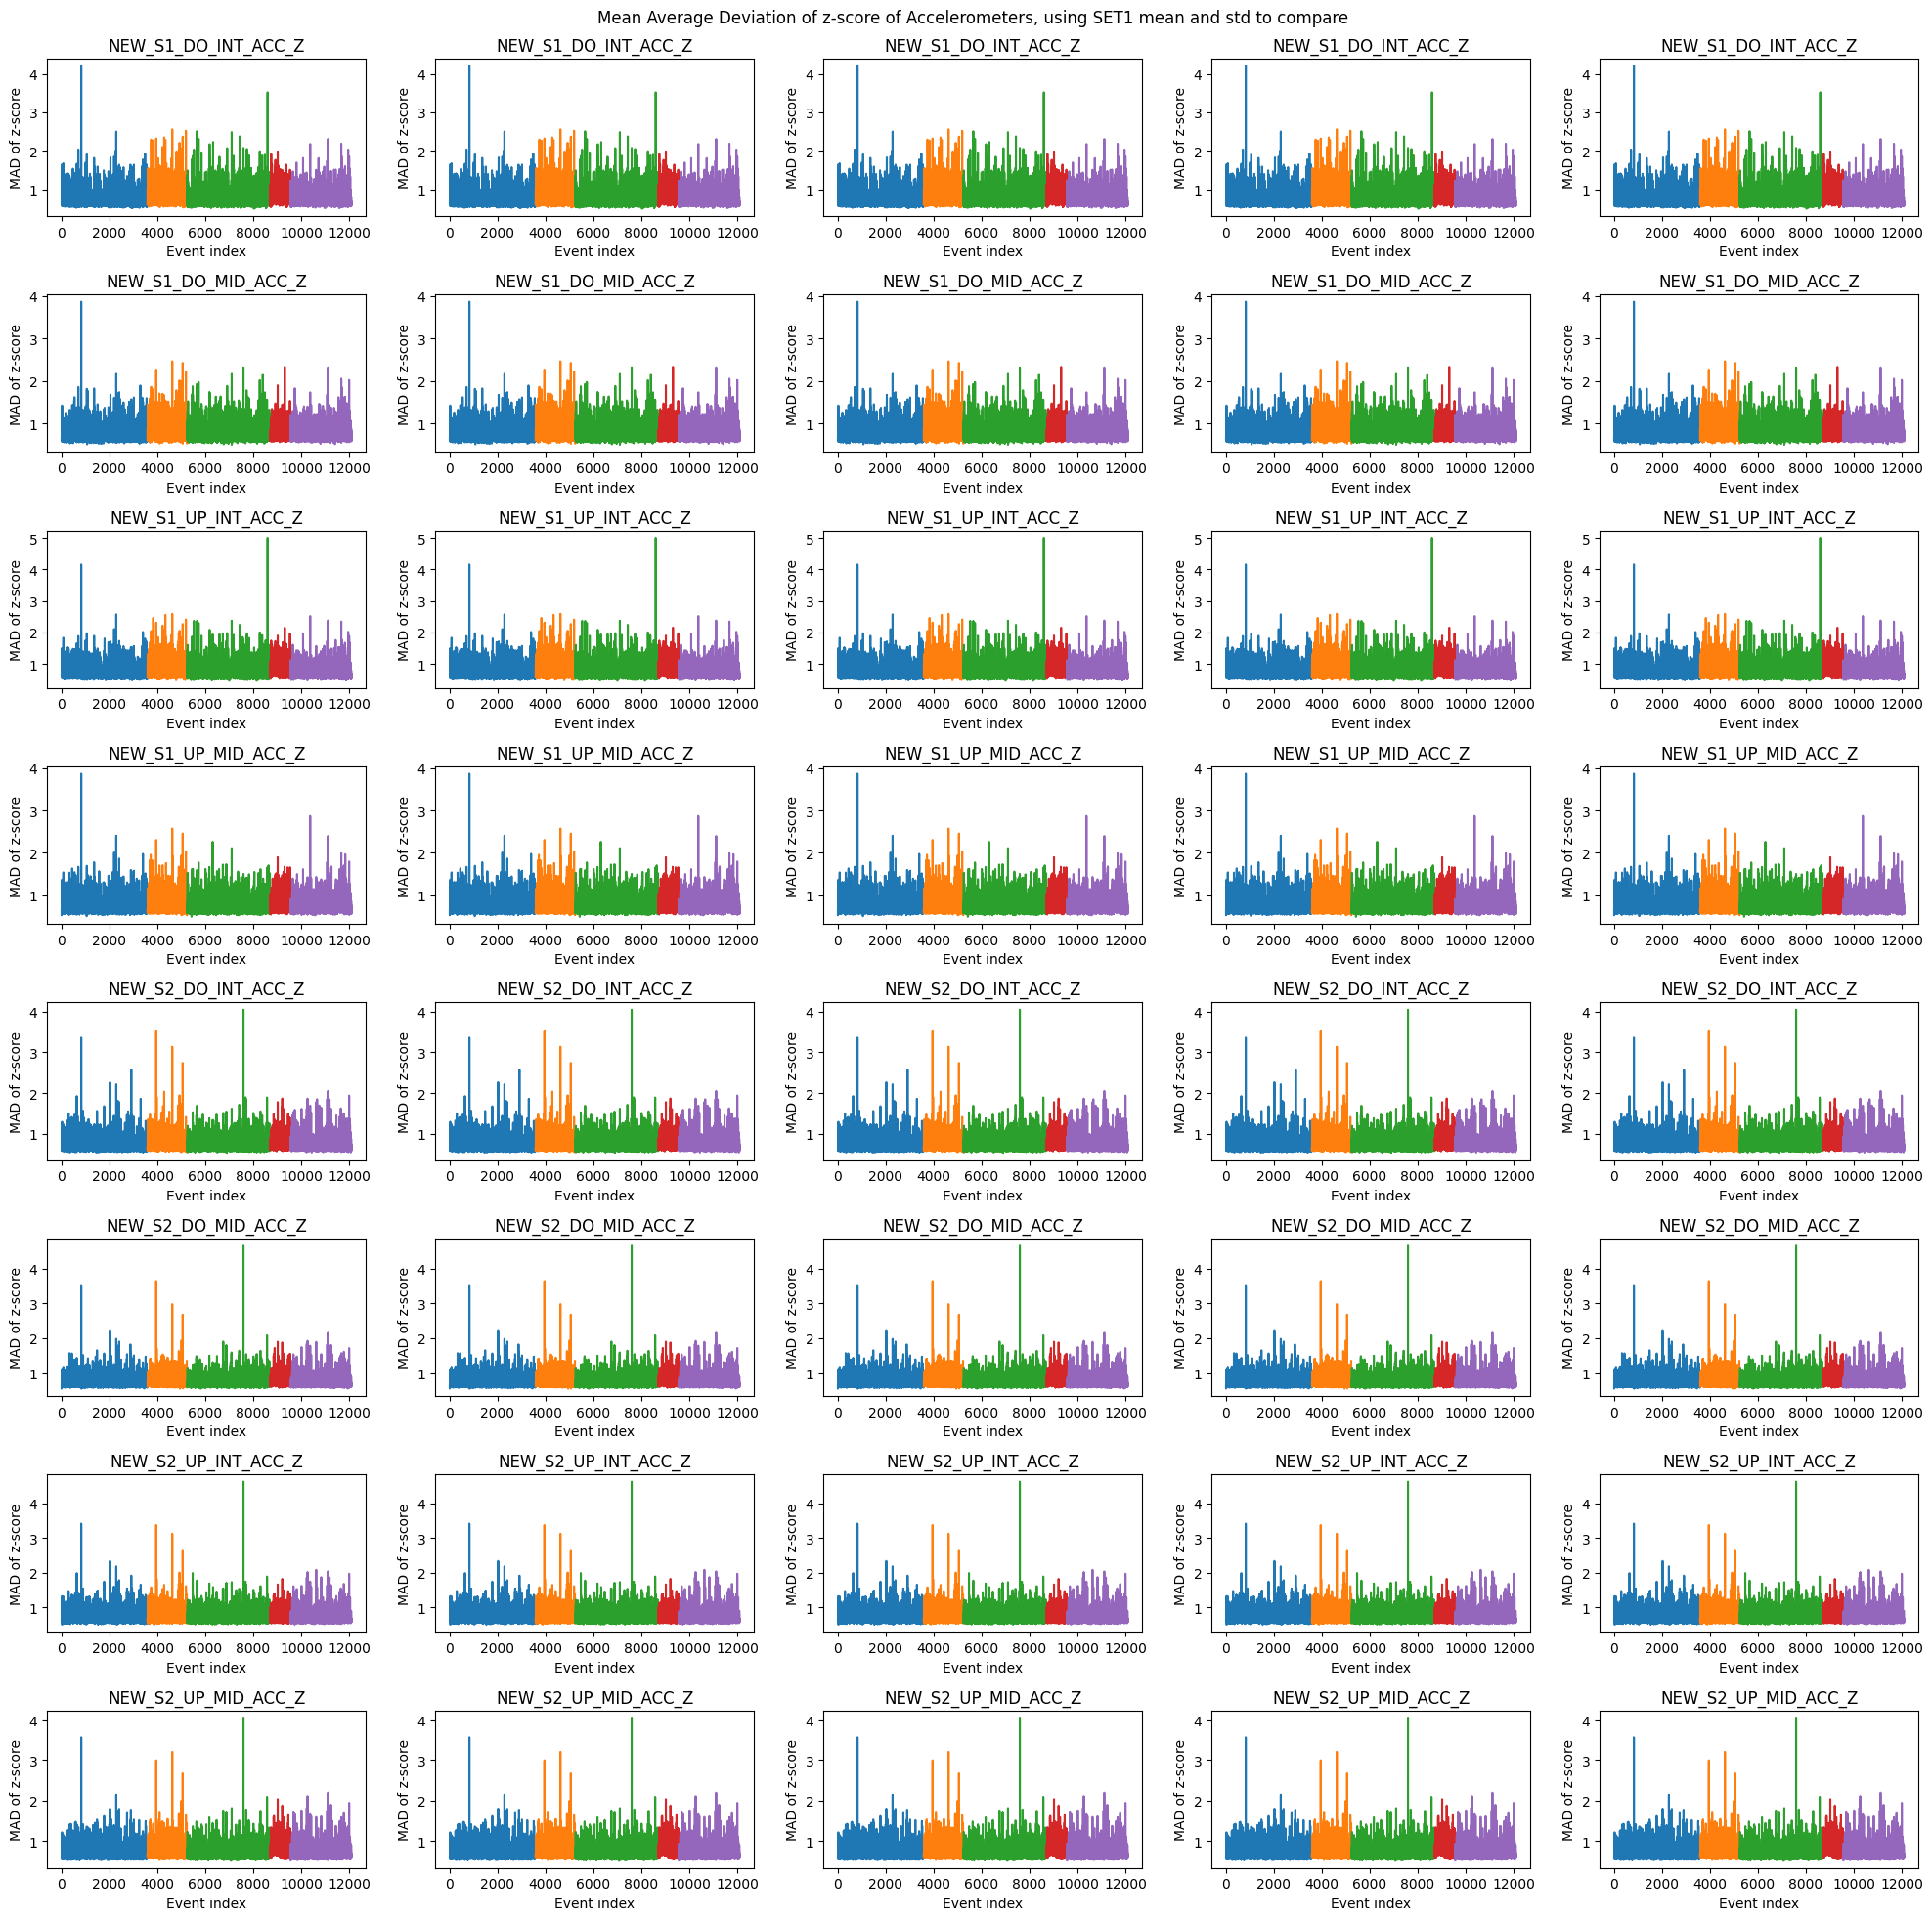

In [120]:
mask = [event_id.startswith('AQUINAS_SET1') for event_id in event_ids]

mu = acc[mask].mean(axis = 0)
sigma = acc[mask].std(axis = 0)


sets = ['AQUINAS_SET1','AQUINAS_SET2','AQUINAS_SET3','AQUINAS_SET4','AQUINAS_SET5']

plt.figure(figsize = (20,20))
idx = 0
for set_name in sets:

    set_mask = [event_id.startswith(set_name) for event_id in event_ids]

    set_z = (acc[set_mask] - mu) / sigma

    set_mad = np.mean(np.abs(set_z), axis = 1)

    for i in range(set_mad.shape[1]):
        plt.subplot(8,5,i+1)
        plt.plot(np.arange(idx, len(set_mad)+idx),set_mad[:,i])
        plt.title(sensor_names['acc_z'][i])
        plt.ylabel('MAD of z-score')
        plt.xlabel('Event index')

    idx += len(set_mad)


plt.suptitle('Mean Average Deviation of z-score of Accelerometers, using SET1 mean and std to compare\n')
plt.tight_layout()
plt.show()


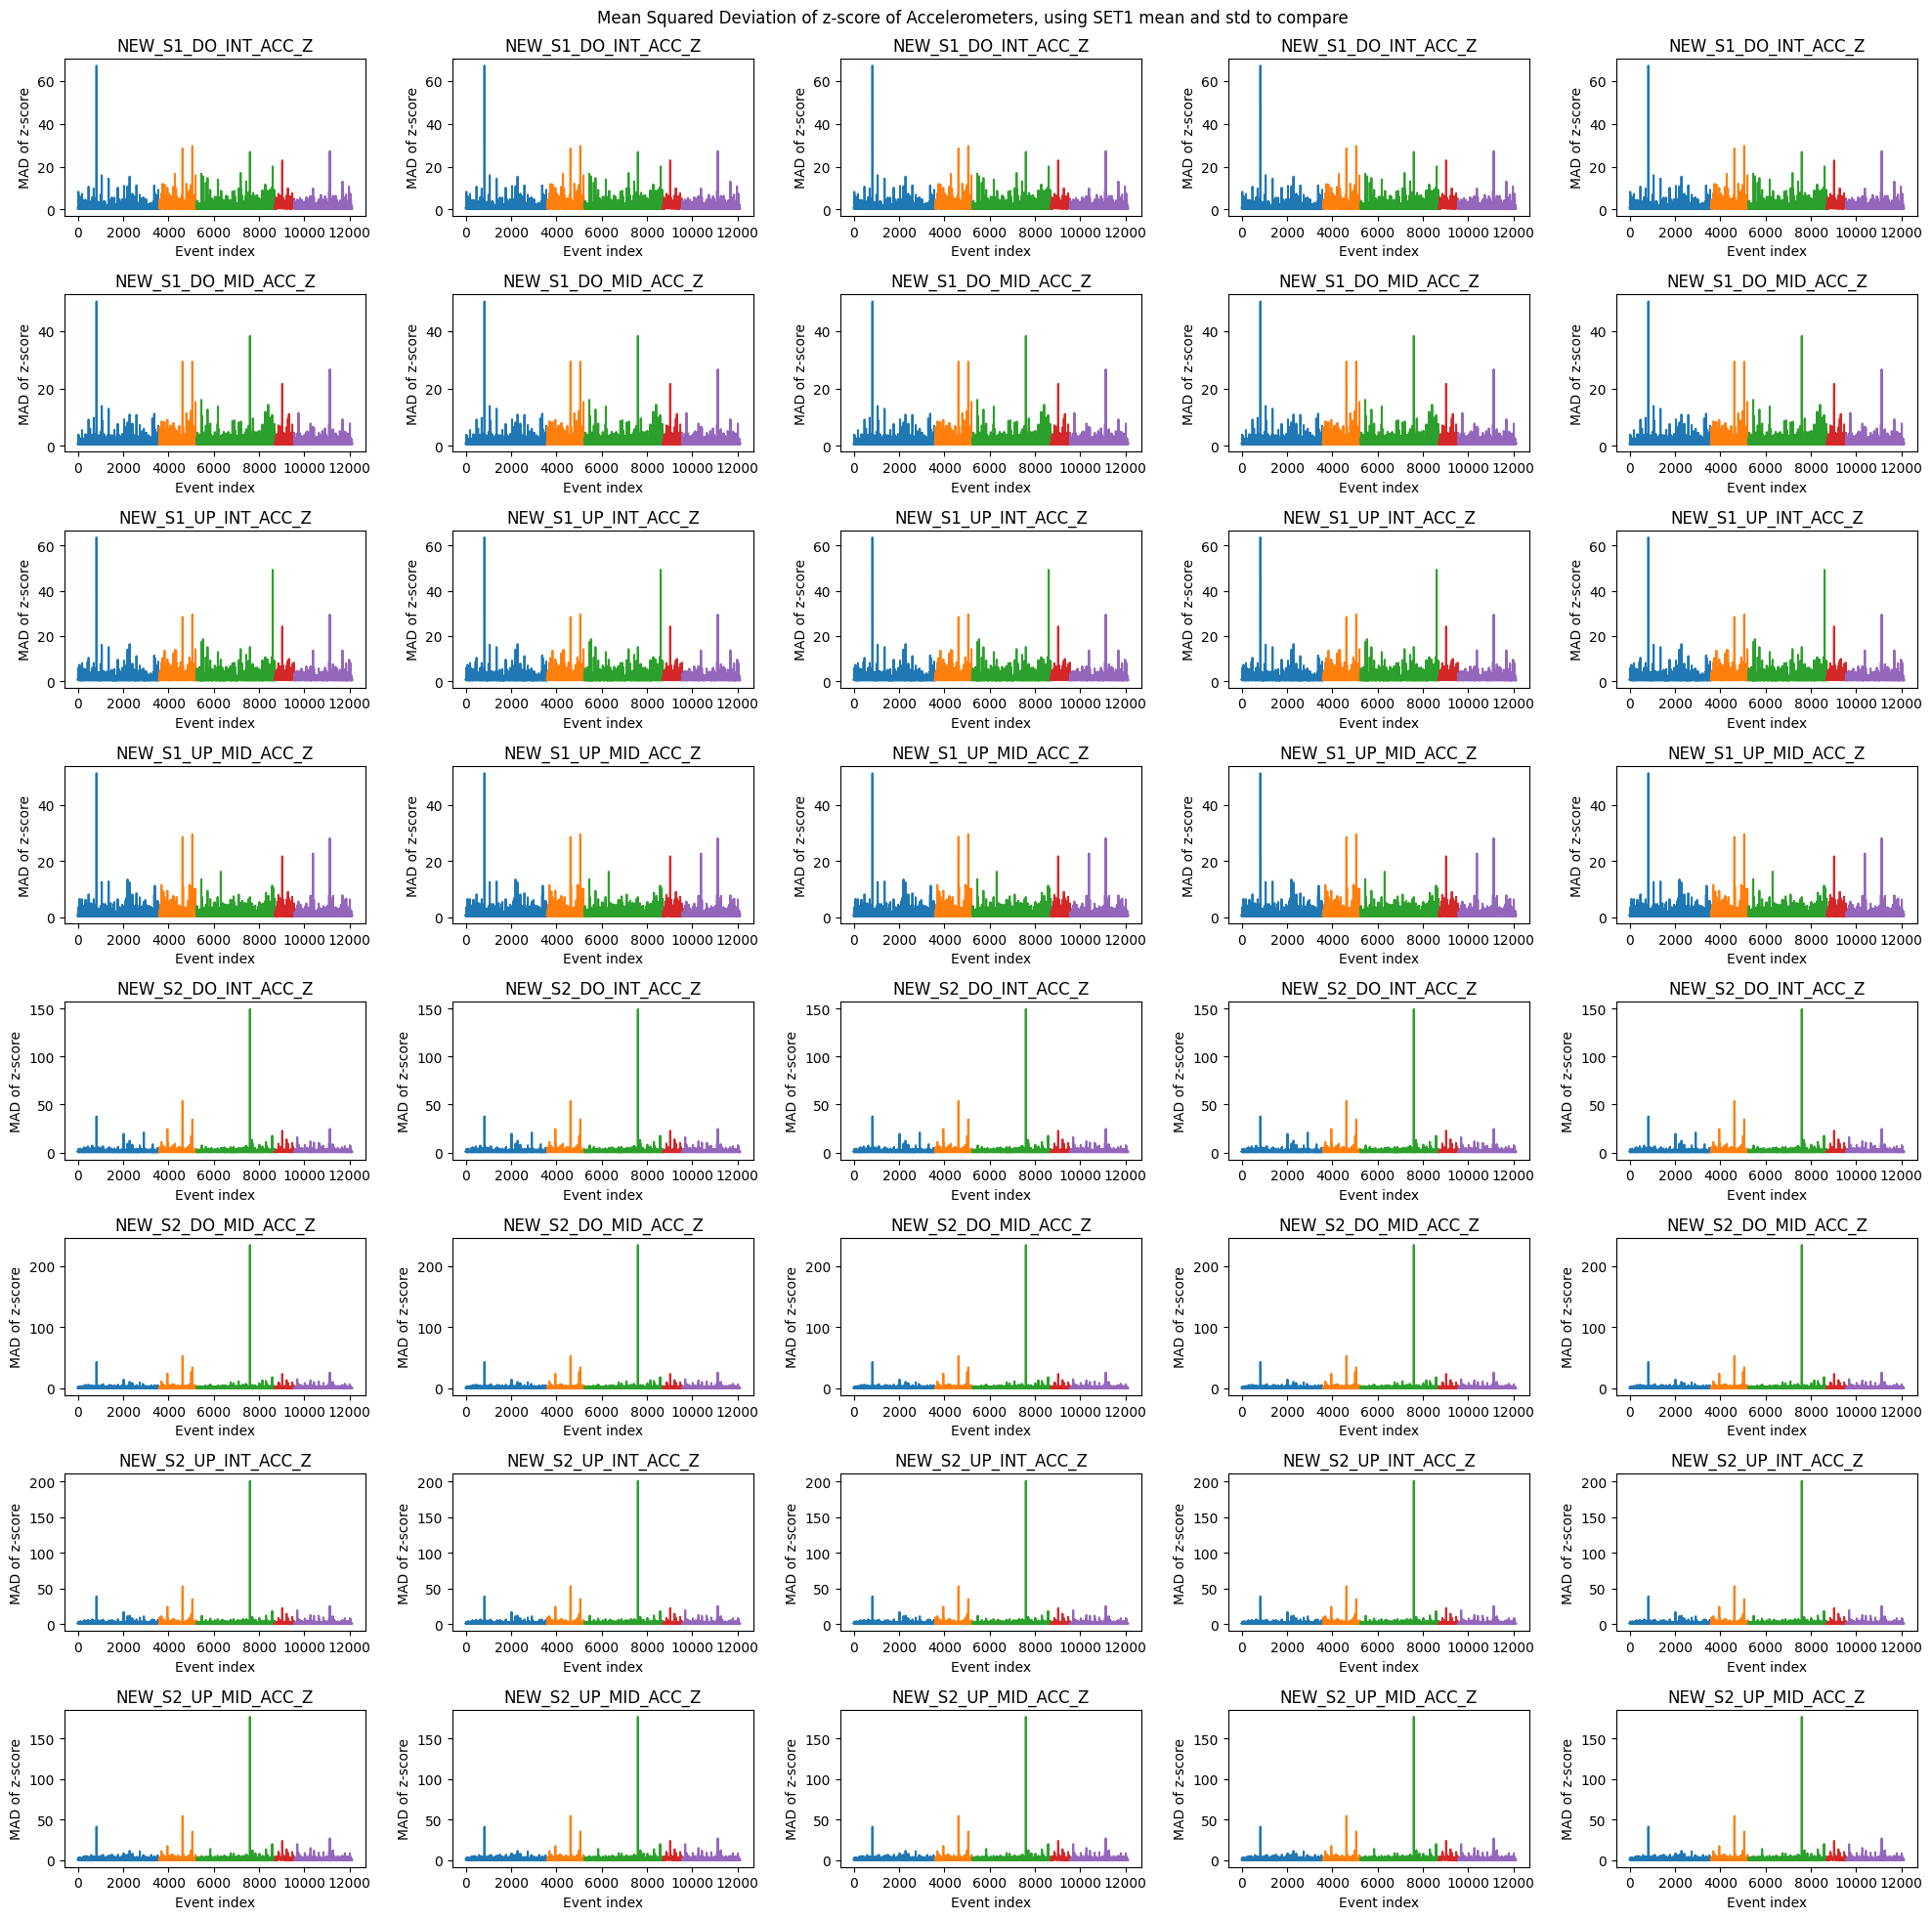

In [121]:
mask = [event_id.startswith('AQUINAS_SET1') for event_id in event_ids]

mu = acc[mask].mean(axis = 0)
sigma = acc[mask].std(axis = 0)


sets = ['AQUINAS_SET1','AQUINAS_SET2','AQUINAS_SET3','AQUINAS_SET4','AQUINAS_SET5']

plt.figure(figsize = (20,20))
idx = 0
for set_name in sets:

    set_mask = [event_id.startswith(set_name) for event_id in event_ids]

    set_z = (acc[set_mask] - mu) / sigma

    set_mad = np.mean((set_z)**2, axis = 1)

    for i in range(set_mad.shape[1]):
        plt.subplot(8,5,i+1)
        plt.plot(np.arange(idx, len(set_mad)+idx),set_mad[:,i])
        plt.title(sensor_names['acc_z'][i])
        plt.ylabel('MAD of z-score')
        plt.xlabel('Event index')

    idx += len(set_mad)


plt.suptitle('Mean Squared Deviation of z-score of Accelerometers, using SET1 mean and std to compare\n')
plt.tight_layout()
plt.show()





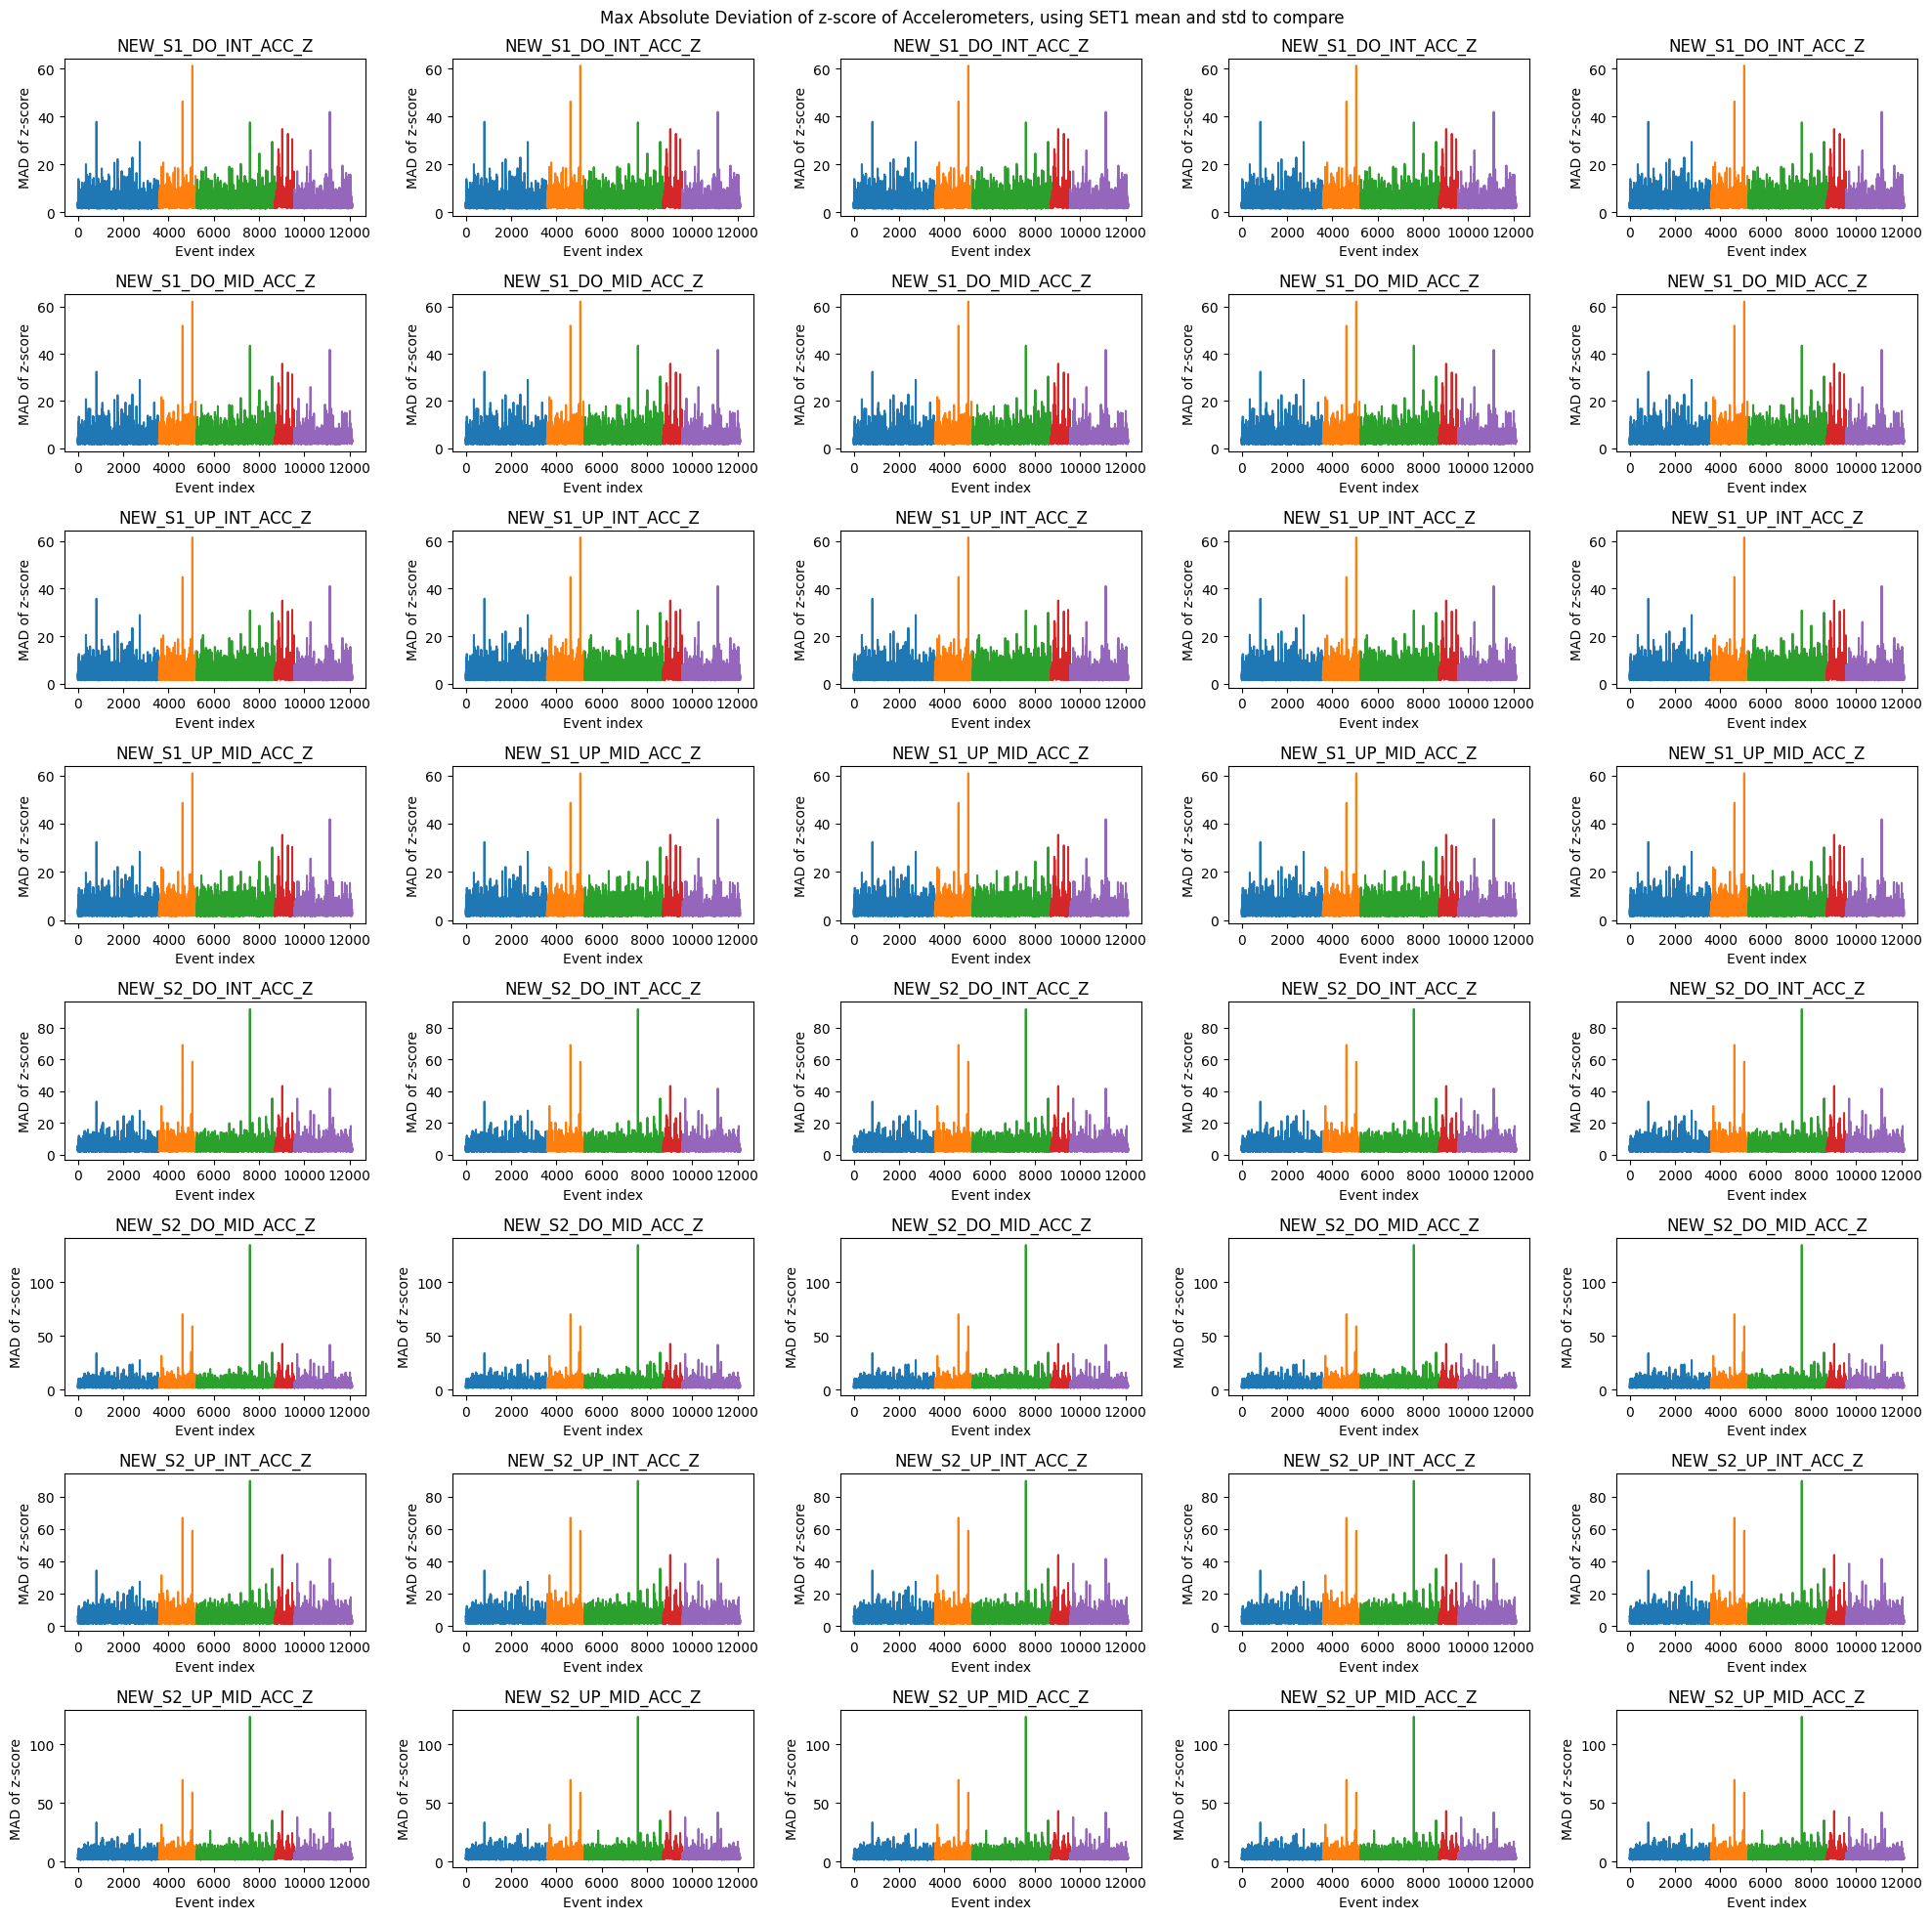

In [124]:
mask = [event_id.startswith('AQUINAS_SET1') for event_id in event_ids]

mu = acc[mask].mean(axis = 0)
sigma = acc[mask].std(axis = 0)


sets = ['AQUINAS_SET1','AQUINAS_SET2','AQUINAS_SET3','AQUINAS_SET4','AQUINAS_SET5']

plt.figure(figsize = (20,20))
idx = 0
for set_name in sets:

    set_mask = [event_id.startswith(set_name) for event_id in event_ids]

    set_z = (acc[set_mask] - mu) / sigma

    set_mad = np.max(np.abs(set_z), axis = 1)

    for i in range(set_mad.shape[1]):
        plt.subplot(8,5,i+1)
        plt.plot(np.arange(idx, len(set_mad)+idx),set_mad[:,i])
        plt.title(sensor_names['acc_z'][i])
        plt.ylabel('MAD of z-score')
        plt.xlabel('Event index')

    idx += len(set_mad)


plt.suptitle('Max Absolute Deviation of z-score of Accelerometers, using SET1 mean and std to compare\n')
plt.tight_layout()
plt.show()





In [ ]:
mask = [event_id.startswith('AQUINAS_SET1') for event_id in event_ids]

isos = [IsolationForest() for i in range(40)]

[isos[i].fit(acc[mask][:,:,i]) for i in range(40)]


plt.figure(figsize = (20,20))
idx = 0
for set_name in sets:

    set_mask = [event_id.startswith(set_name) for event_id in event_ids]

    #This one gives a score-per-event from IsolationForest
    set_mad = [isos[i].decision_function(acc[set_mask][:,:,i]) for i in range(40)]

    for i in range(40):
        plt.subplot(8,5,i+1)
        plt.plot(np.arange(idx, len(set_mad[i])+idx),set_mad[i],'.')
        plt.title(sensor_names['acc_z'][i])
        plt.ylabel('Score from IsolationForest\n(higher = better)')
        plt.xlabel('Event index')

    idx += len(set_mad[i])


plt.suptitle('IsolationForest Accelerometers, using SET1 to fit\n')
plt.tight_layout()
plt.show()